# 03 - Recuperacion de precedentes similares

## Resumen amplio

Este notebook implementa retrieval de precedentes. Dado un caso de consulta, ordena casos de entrenamiento por similitud textual para que una persona revise precedentes potencialmente utiles. No afirma identidad juridica ni predice sentencia.

Se comparan **TF-IDF + coseno** y **TF-IDF + SVD + coseno**. La relevancia operacional se define como compartir al menos un articulo real con la consulta. Es una aproximacion cuantitativa util, pero no sustituye validacion doctrinal humana.

## Indice

1. Carga de casos y etiquetas.
2. Que son TF-IDF, coseno y SVD.
3. Definicion de relevancia y metricas.
4. TF-IDF + coseno.
5. TF-IDF + SVD + coseno.
6. Ejemplo real de consulta y precedentes.
7. Figura y artefactos.


![Esquema especifico generado con Image Gen](artifacts/figures/generated/notebook_03_retrieval_v2.png)

**Lectura del esquema.** La imagen resume retrieval: una consulta real se compara contra un indice construido solo con train y devuelve un ranking top-k de precedentes candidatos. La imagen es conceptual; las cifras y conclusiones se calculan en las celdas del notebook con datos reales.


In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import project_utils as pu
warnings.filterwarnings('ignore')
pu.configure(); sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 180)


## 1. Datos para retrieval

El indice contiene solo `train`; las consultas vienen de `validation` y `test`. La muestra hace el notebook interactivo y reproducible.


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import joblib

pu.materialize_database(force=False)
cases, labels, articles = pu.load_cases_labels()
y = pu.multilabel_matrix(labels, cases['case_id'], articles)
case_labels_sets = {case_id: set(y.columns[y.loc[case_id].to_numpy().astype(bool)]) for case_id in y.index}
train = cases[cases['split']=='train'].sample(n=2500, random_state=pu.SEED).sort_values('case_id').reset_index(drop=True)
queries = pd.concat([cases[cases['split']=='validation'].sample(n=250, random_state=pu.SEED), cases[cases['split']=='test'].sample(n=250, random_state=pu.SEED)]).sort_values(['split','case_id']).reset_index(drop=True)
print(train.shape, queries.shape); display(train[['case_id','n_tokens']].head()); display(queries[['case_id','split','n_tokens']].head())


(2500, 7) (500, 7)


,case_id,n_tokens
0,ecthr_task_b_train_000000,7014
1,ecthr_task_b_train_000003,3907
2,ecthr_task_b_train_000008,1712
3,ecthr_task_b_train_000014,3214
4,ecthr_task_b_train_000017,828


,case_id,split,n_tokens
0,ecthr_task_b_test_000002,test,302
1,ecthr_task_b_test_000003,test,644
2,ecthr_task_b_test_000010,test,206
3,ecthr_task_b_test_000023,test,785
4,ecthr_task_b_test_000025,test,2160


## 2. Que son TF-IDF, coseno y SVD

**TF** significa *term frequency*: cuantas veces aparece un termino en un documento. En este notebook los terminos pueden ser palabras sueltas o bigramas, por ejemplo `fair trial`.

**IDF** significa *inverse document frequency*: reduce el peso de terminos demasiado comunes en casi todos los casos y aumenta el peso de terminos mas especificos. Por eso `court` o `applicant` suelen pesar menos que expresiones mas discriminativas.

**TF-IDF** combina ambas ideas: un caso se convierte en un vector enorme donde cada columna representa un termino/bigrama y cada valor representa lo caracteristico que es ese termino en ese caso. No se cuentan articulos ni etiquetas: se vectoriza texto.

**Coseno** compara la direccion de dos vectores. Si dos casos usan vocabulario parecido, sus vectores apuntan en direcciones similares y el score de coseno sube. Esto es util con documentos juridicos de longitudes muy distintas porque no compara solo tamano del texto.

**SVD** (*Singular Value Decomposition*) no es una red neuronal. Aqui reduce la matriz TF-IDF dispersa a 256 dimensiones densas. La idea es agrupar patrones de vocabulario: casos que no comparten exactamente las mismas palabras pueden quedar cerca si sus terminos aparecen en contextos parecidos. La contrapartida es que se pierde interpretabilidad directa por termino.

In [3]:
mini_docs = [
    'fair trial hearing court evidence',
    'detention police custody unlawful',
    'fair hearing independent tribunal',
]
mini_vectorizer = TfidfVectorizer(ngram_range=(1, 1), lowercase=True)
mini_x = mini_vectorizer.fit_transform(mini_docs)
mini_tfidf = pd.DataFrame(
    mini_x.toarray(),
    columns=mini_vectorizer.get_feature_names_out(),
    index=['doc_1_trial', 'doc_2_detention', 'doc_3_trial'],
)

mini_similarity = pd.DataFrame(
    cosine_similarity(mini_x),
    index=mini_tfidf.index,
    columns=mini_tfidf.index,
)

display(mini_tfidf.round(3))
display(mini_similarity.round(3))


,court,custody,detention,evidence,fair,hearing,independent,police,trial,tribunal,unlawful
doc_1_trial,0.49,0.0,0.0,0.49,0.373,0.373,0.000,0.0,0.49,0.000,0.0
doc_2_detention,0.00,0.5,0.5,0.00,0.000,0.000,0.000,0.5,0.00,0.000,0.5
doc_3_trial,0.00,0.0,0.0,0.00,0.428,0.428,0.563,0.0,0.00,0.563,0.0


,doc_1_trial,doc_2_detention,doc_3_trial
doc_1_trial,1.000,0.0,0.319
doc_2_detention,0.000,1.0,0.000
doc_3_trial,0.319,0.0,1.000


En el ejemplo pequeno, `doc_1_trial` y `doc_3_trial` deberian parecerse mas entre si porque comparten vocabulario de juicio justo. En el notebook real se hace lo mismo, pero con miles de casos y hasta 80.000 columnas TF-IDF.

## 3. Metricas de ranking

`Recall@5` y `Recall@10` indican si aparece al menos un precedente relevante en las primeras posiciones. `nDCG@10` premia que los relevantes aparezcan arriba.


In [4]:
def ndcg_at_k(relevances, k=10):
    """Calcula nDCG@k para una secuencia binaria de relevancias.

    Entrada:
        relevances: lista donde 1 significa resultado relevante.
        k: profundidad del ranking evaluada.

    Salida:
        nDCG@k entre 0 y 1. Premia que los relevantes aparezcan arriba.
    """
    rel = np.asarray(list(relevances)[:k], dtype=float)
    if rel.size == 0:
        return 0.0
    discounts = 1.0 / np.log2(np.arange(2, rel.size + 2))
    dcg = float(np.sum(rel * discounts))
    ideal = np.sort(rel)[::-1]
    idcg = float(np.sum(ideal * discounts))
    return dcg / idcg if idcg else 0.0


def recall_at_k(relevances, k=10):
    """Indica si aparece algun resultado relevante en el top-k.

    Entrada:
        relevances: lista binaria de relevancias ordenadas por ranking.
        k: profundidad evaluada.

    Salida:
        `1.0` si hay al menos un relevante en las primeras `k` posiciones;
        `0.0` en caso contrario.
    """
    return float(any(list(relevances)[:k]))


def evaluate_rankings(method_name, query_df, train_df, score_matrix, top_k=10):
    """Evalua un ranking de precedentes con relevancia por articulos compartidos.

    Entrada:
        method_name: nombre del metodo de retrieval evaluado.
        query_df: consultas reales de validation/test.
        train_df: casos indexados como precedentes candidatos.
        score_matrix: matriz `(n_consultas, n_train)` con similitudes.
        top_k: profundidad maxima guardada y evaluada.

    Salida:
        `(rankings, metrics)`:
        - `rankings`: una fila por consulta y posicion recuperada.
        - `metrics`: Recall@5, Recall@10 y nDCG@10 por consulta.

    Criterio de relevancia:
        Un precedente cuenta como relevante si comparte al menos un articulo real
        con la consulta. Es una definicion operacional para evaluar a escala, no
        una equivalencia juridica completa.
    """
    rows=[]; metric_rows=[]; train_ids=train_df['case_id'].tolist()
    for q_idx, q in query_df.iterrows():
        order=np.argsort(score_matrix[q_idx])[::-1][:top_k]; q_labels=case_labels_sets[q['case_id']]; relevances=[]
        for rank, train_pos in enumerate(order, start=1):
            retrieved=train_ids[train_pos]; relevant=int(bool(q_labels & case_labels_sets[retrieved])); relevances.append(relevant)
            rows.append({'query_case_id':q['case_id'],'rank':rank,'retrieved_case_id':retrieved,'relevant':relevant,'score':float(score_matrix[q_idx,train_pos]),'split':q['split'],'method':method_name})
        metric_rows.append({'retrieval_method':method_name,'split':q['split'],'query_case_id':q['case_id'],'has_relevant':int(any(relevances)),'recall_at_5':recall_at_k(relevances,5),'recall_at_10':recall_at_k(relevances,10),'ndcg_at_10':ndcg_at_k(relevances,10)})
    return pd.DataFrame(rows), pd.DataFrame(metric_rows)


## 4. TF-IDF + coseno

Este metodo construye el indice de precedentes asi:

1. Ajusta `TfidfVectorizer` solo con casos de `train`.
2. Transforma consultas de `validation` y `test` con el mismo vocabulario.
3. Calcula `cosine_similarity(query_x, train_x)`.
4. Para cada consulta, ordena los casos de train de mayor a menor similitud.
5. Evalua si los primeros resultados comparten algun articulo real con la consulta.

La matriz `tfidf_scores` tiene forma `(n_consultas, n_precedentes_train)`: cada celda es la similitud textual entre una consulta y un candidato de train.

In [5]:
retrieval_vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95, max_features=80000, sublinear_tf=True, strip_accents='unicode', lowercase=True, dtype=np.float32)
train_x = retrieval_vectorizer.fit_transform(train['text_full']); query_x = retrieval_vectorizer.transform(queries['text_full'])
tfidf_scores = cosine_similarity(query_x, train_x)
tfidf_rankings, tfidf_metrics = evaluate_rankings('tfidf_cosine_sampled', queries, train, tfidf_scores)
display(tfidf_metrics.groupby(['retrieval_method','split']).agg(n_queries=('query_case_id','count'), n_queries_with_relevant=('has_relevant','sum'), ndcg_at_10=('ndcg_at_10','mean'), recall_at_5=('recall_at_5','mean'), recall_at_10=('recall_at_10','mean')).reset_index())


,retrieval_method,split,n_queries,n_queries_with_relevant,ndcg_at_10,recall_at_5,recall_at_10
0,tfidf_cosine_sampled,test,250,243,0.867492,0.944,0.972
1,tfidf_cosine_sampled,validation,250,241,0.882248,0.952,0.964


## 5. TF-IDF + SVD + coseno

SVD toma la matriz TF-IDF y la proyecta a un espacio denso de 256 dimensiones. Despues se vuelve a calcular coseno en ese espacio compacto.

La diferencia practica es esta:

- `TF-IDF + coseno`: busca coincidencia lexical directa, mas interpretable por terminos.
- `TF-IDF + SVD + coseno`: busca similitud latente, puede agrupar vocabulario relacionado aunque no sea identico.

SVD no ve las etiquetas. Solo resume patrones del texto. Las etiquetas se usan despues para evaluar si los precedentes recuperados comparten articulos con la consulta.

In [6]:
svd = TruncatedSVD(n_components=256, random_state=pu.SEED)
train_z = svd.fit_transform(train_x); query_z = svd.transform(query_x)
svd_scores = cosine_similarity(query_z, train_z)
svd_rankings, svd_metrics = evaluate_rankings('tfidf_svd_cosine_sampled', queries, train, svd_scores)
headline = pd.concat([tfidf_metrics, svd_metrics]).groupby(['retrieval_method','split']).agg(n_queries=('query_case_id','count'), n_queries_with_relevant=('has_relevant','sum'), ndcg_at_10=('ndcg_at_10','mean'), recall_at_5=('recall_at_5','mean'), recall_at_10=('recall_at_10','mean')).reset_index()
headline.to_csv(pu.METRICS/'retrieval_tfidf_headline.csv', index=False); headline.to_csv(pu.METRICS/'paper_retrieval_table.csv', index=False)
rankings = pd.concat([tfidf_rankings, svd_rankings], ignore_index=True); rankings.to_csv(pu.METRICS/'retrieval_tfidf_rankings.csv', index=False)
joblib.dump({'vectorizer':retrieval_vectorizer,'svd':svd,'train_case_ids':train['case_id'].tolist()}, pu.INDICES/'notebook_retrieval_tfidf_svd_index.joblib')
display(headline)


,retrieval_method,split,n_queries,n_queries_with_relevant,ndcg_at_10,recall_at_5,recall_at_10
0,tfidf_cosine_sampled,test,250,243,0.867492,0.944,0.972
1,tfidf_cosine_sampled,validation,250,241,0.882248,0.952,0.964
2,tfidf_svd_cosine_sampled,test,250,239,0.875893,0.940,0.956
3,tfidf_svd_cosine_sampled,validation,250,241,0.898132,0.960,0.964


### Interpretacion de la tabla de retrieval

`Recall@10` responde a una pregunta practica: si el usuario revisa diez precedentes, aparece al menos uno que comparte articulo real con la consulta? `nDCG@10` es mas exigente porque premia que ese precedente aparezca arriba. Una puntuacion alta no significa que el precedente sea doctrinalmente equivalente; significa que, bajo la definicion operacional de relevancia, el ranking pone casos utiles pronto.

La variante SVD puede mejorar `nDCG` porque agrupa patrones de vocabulario, pero tambien pierde interpretabilidad directa: ya no se puede explicar el ranking solo mirando terminos TF-IDF originales.


## 6. Ejemplo real de precedentes recuperados

La consulta y los precedentes son casos reales. Se muestran articulos compartidos para interpretar la relevancia operacional. El ejemplo compara el top-5 de TF-IDF puro y el top-5 de TF-IDF+SVD para la misma consulta.

In [7]:
query_id = rankings[(rankings['split']=='test') & (rankings['method']=='tfidf_cosine_sampled')].iloc[0]['query_case_id']
query_summary = pu.summarize_case(query_id, max_chars=900)
query_articles = sorted(case_labels_sets[query_id])

print(f'Consulta: {query_id}')
print(f'Articulos reales de la consulta: {", ".join(query_articles)}')
display(pd.DataFrame([query_summary]))

example_rows = []
for method_name in ['tfidf_cosine_sampled', 'tfidf_svd_cosine_sampled']:
    example_rank = rankings[(rankings['query_case_id'] == query_id) & (rankings['method'] == method_name)].head(5)
    for row in example_rank.itertuples(index=False):
        retrieved_summary = pu.summarize_case(row.retrieved_case_id, max_chars=420)
        shared = sorted(case_labels_sets[query_id] & case_labels_sets[row.retrieved_case_id])
        example_rows.append({
            'method': method_name,
            'rank': row.rank,
            'retrieved_case_id': row.retrieved_case_id,
            'score': row.score,
            'relevant': row.relevant,
            'shared_articles': ', '.join(shared) or '(ninguno)',
            'retrieved_excerpt': retrieved_summary['excerpt'],
        })

example_df = pd.DataFrame(example_rows)
display(example_df)


Consulta: ecthr_task_b_test_000002
Articulos reales de la consulta: 6


,case_id,task,split,year,n_paragraphs,n_tokens,excerpt,article_codes
0,ecthr_task_b_test_000002,ecthr_task_b,test,None,8,302,5. The applicant was born in 1965 and lives in Smědčice. 6. On 9 November 2006 the applicant requested a building permit for temporary stables for horses. On 6 January 2011 ...,6


,method,rank,retrieved_case_id,score,relevant,shared_articles,retrieved_excerpt
0,tfidf_cosine_sampled,1,ecthr_task_b_train_008248,0.163510,1,6,5. The applicant was born in 1952 and lives in Šaľa. 6. On 31 May 1994 the applicant claimed a sum of money from a bank. 7. On 16 September 2005 the applicant lodged an ap...
1,tfidf_cosine_sampled,2,ecthr_task_b_train_005972,0.145823,0,(ninguno),"5. The applicant is a Czech national born in 1946 who lives in Vysoké Mýto (the Czech Republic). 6. The applicant was married from 1971 until 1998, when he divorced. On 28 M..."
2,tfidf_cosine_sampled,3,ecthr_task_b_train_008569,0.143453,0,(ninguno),"6. The applicants were born in 1972, 1949 and 1950 respectively. The first applicant lives in Sydney, Australia and the second and third applicants live in Skopje. 7. On 19 ..."
3,tfidf_cosine_sampled,4,ecthr_task_b_train_001783,0.133451,1,6,"4. The applicant was born in 1948 and lives in Prague. 5. The applicant’s grandmother owned a house and plot of land in Městec Králové, which the State seized in 1960 and re..."
4,tfidf_cosine_sampled,5,ecthr_task_b_train_007165,0.130701,1,6,"4. The applicant was born in 1965 and lives in Willstätt, Germany. He was a minority shareholder of IVAX CR, a.s., a joint stock company incorporated under Czech law. 5. On ..."
5,tfidf_svd_cosine_sampled,1,ecthr_task_b_train_008248,0.565153,1,6,5. The applicant was born in 1952 and lives in Šaľa. 6. On 31 May 1994 the applicant claimed a sum of money from a bank. 7. On 16 September 2005 the applicant lodged an ap...
6,tfidf_svd_cosine_sampled,2,ecthr_task_b_train_008176,0.541944,0,(ninguno),5. The applicant was born in 1969 and lives in Podgorica. 6. On 8 May 2001 the applicant murdered X and immediately thereafter left the country. 7. On 6 March 2002 the app...
7,tfidf_svd_cosine_sampled,3,ecthr_task_b_train_005972,0.510726,0,(ninguno),"5. The applicant is a Czech national born in 1946 who lives in Vysoké Mýto (the Czech Republic). 6. The applicant was married from 1971 until 1998, when he divorced. On 28 M..."
8,tfidf_svd_cosine_sampled,4,ecthr_task_b_train_001180,0.501158,1,6,"8. Criminal proceedings had been pending since 1997 against the applicant, who had absconded. On 12 February 1998 he was arrested by the police and remanded in custody by the ..."
9,tfidf_svd_cosine_sampled,5,ecthr_task_b_train_008693,0.500945,1,6,5. The applicant was born in 1953 and lives in Split. 6. On 5 June 1992 the Customs Office Sežana in customs offence proceedings seized a large amount of gold belonging to t...


## 7. Figura y resultado

`Recall@10` es especialmente importante porque mide si la lista corta contiene al menos un precedente con articulo compartido.


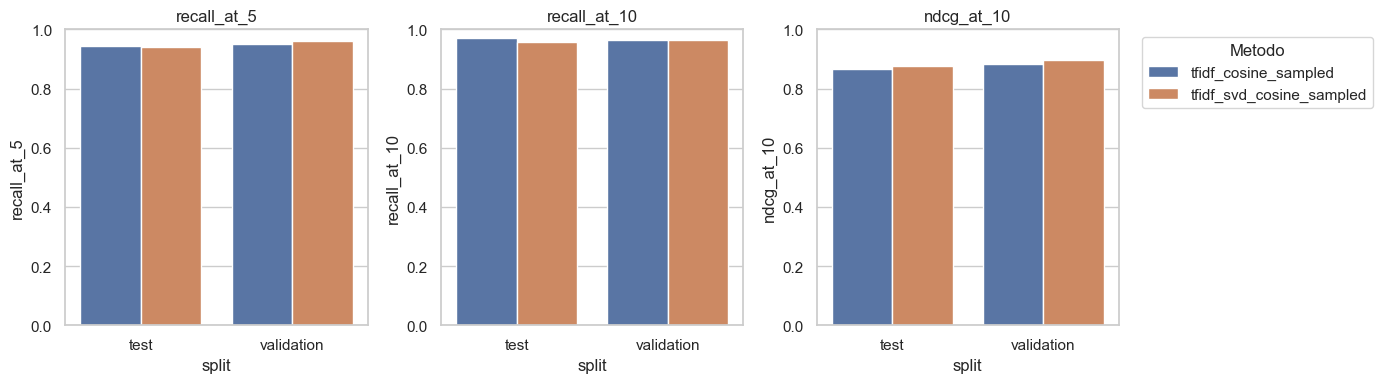

In [8]:
fig, axes = plt.subplots(1,3,figsize=(14,4))
for ax, metric in zip(axes, ['recall_at_5','recall_at_10','ndcg_at_10']):
    sns.barplot(data=headline,x='split',y=metric,hue='retrieval_method',ax=ax); ax.set_ylim(0,1); ax.set_title(metric)
axes[0].legend_.remove(); axes[1].legend_.remove(); axes[2].legend(title='Metodo', bbox_to_anchor=(1.05,1), loc='upper left')
fig.tight_layout(); fig.savefig(pu.FIGURES/'fig05_retrieval_precedents.png', dpi=180); plt.show()
